In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

In [6]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "titanic_dataset" / "Titanic-Dataset.csv"
df = pd.read_csv(train_path)

In [7]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[features]
y = df["Survived"]
num_cols = ["Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Pclass", "Sex", "Embarked"]

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
model = Pipeline([
    ("preprocess", preprocess),
    ("tree", DecisionTreeClassifier(
        max_depth=4, min_samples_leaf=12, random_state=42
    )),
])

In [8]:
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)
print("training accuracy:", round(accuracy_score(y_train, train_pred), 3))
print("validation accuracy:", round(accuracy_score(y_valid, valid_pred), 3))

training accuracy: 0.843
validation accuracy: 0.767


In [9]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
print(export_text(
    model.named_steps["tree"],
    feature_names=list(feature_names),
    max_depth=3,
))

|--- cat__Sex_female <= 0.50
|   |--- num__Age <= 3.50
|   |   |--- class: 1
|   |--- num__Age >  3.50
|   |   |--- cat__Pclass_1 <= 0.50
|   |   |   |--- num__Fare <= 48.09
|   |   |   |   |--- class: 0
|   |   |   |--- num__Fare >  48.09
|   |   |   |   |--- class: 0
|   |   |--- cat__Pclass_1 >  0.50
|   |   |   |--- num__Age <= 53.00
|   |   |   |   |--- class: 0
|   |   |   |--- num__Age >  53.00
|   |   |   |   |--- class: 0
|--- cat__Sex_female >  0.50
|   |--- cat__Pclass_3 <= 0.50
|   |   |--- num__Fare <= 28.86
|   |   |   |--- num__Age <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- num__Age >  37.00
|   |   |   |   |--- class: 1
|   |   |--- num__Fare >  28.86
|   |   |   |--- num__Parch <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- num__Parch >  1.50
|   |   |   |   |--- class: 1
|   |--- cat__Pclass_3 >  0.50
|   |   |--- num__Fare <= 7.89
|   |   |   |--- cat__Embarked_S <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- cat__Embarked_S >  0.50
|   |

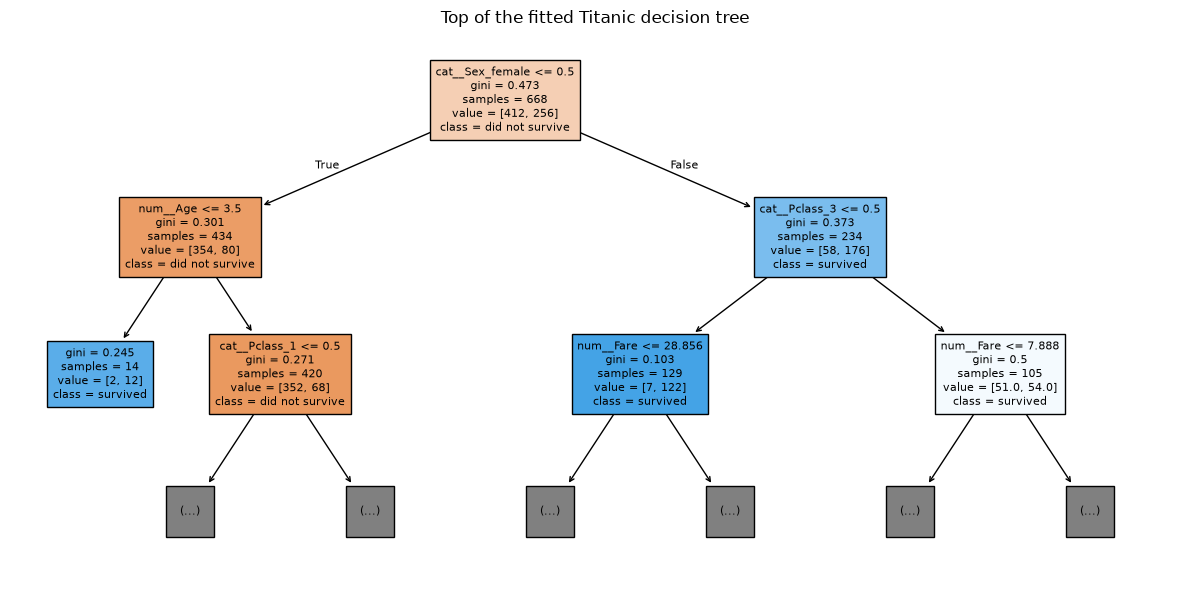

In [10]:
# Plot only the top levels so the learned rules remain readable.
feature_names = model.named_steps["preprocess"].get_feature_names_out()
plt.figure(figsize=(12, 6))
plot_tree(
    model.named_steps["tree"],
    feature_names=feature_names,
    class_names=["did not survive", "survived"],
    max_depth=2,
    filled=True,
    fontsize=8,
)
plt.title("Top of the fitted Titanic decision tree")
plt.tight_layout()
plt.show()